# Segment Anything Model (SAM) Implementation

In [ ]:
# Mount your google drive where you've saved your assignment folder
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:

!ls

drive  sample_data


In [ ]:
import os
from pathlib import Path
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
# 11554880000.jpg
topics = ['tesse_seg_cam_rgb_image_raw', 'tesse_right_cam_mono_image_raw', 'tesse_right_cam_rgb_image_raw', 'tesse_left_cam_mono_image_raw', 'tesse_left_cam_rgb_image_raw']
dataset_dir = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/"

image_dir = "/content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_right_cam_rgb_image_raw/11554880000.jpg"

Processing images in: /content/drive/MyDrive/SBU/Advanced_Project_Robotics/dataset/tesse_right_cam_rgb_image_raw
Found 8307 image files. Displaying the first few:
Reading image: 462154899999.jpg


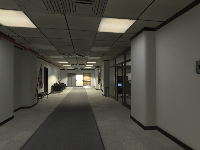

Reading image: 462204900000.jpg


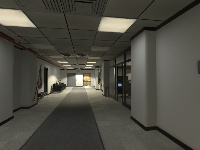

Reading image: 462254900000.jpg


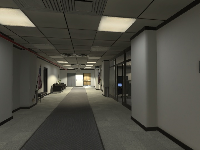

Reading image: 462404899999.jpg


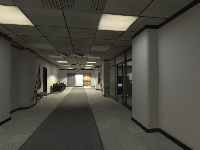

Reading image: 462454900000.jpg


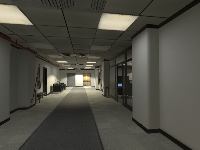

Reading image: 462504900000.jpg


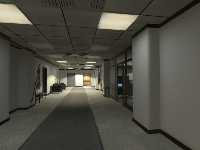

Reading image: 462554899999.jpg


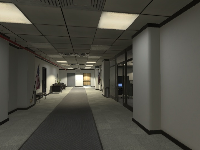

Reading image: 462604899999.jpg


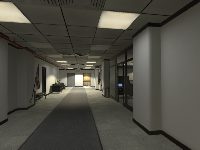

Reading image: 462654899999.jpg


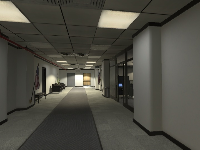

Reading image: 462704900000.jpg


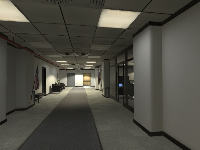

Reading image: 462754900000.jpg


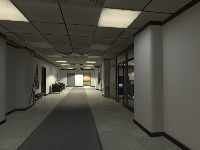

Reading image: 462804899999.jpg


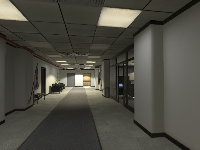

Reading image: 462854899999.jpg


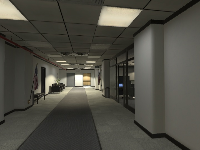

Reading image: 462954900000.jpg


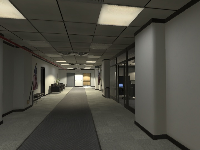

Reading image: 463004900000.jpg


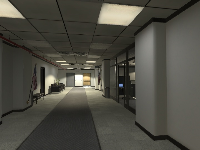

...


In [ ]:
image_dir_path = Path(dataset_dir + topics[2])
print(f"Processing images in: {image_dir_path}")

# Check if the directory exists
if not image_dir_path.is_dir():
    print(f"Error: Directory not found at {image_dir_path}")
else:
    # Iterate through all files in the directory and store the names of the all images in image_files[]
    image_files = []
    for file_path in image_dir_path.iterdir():
        if file_path.is_file() and file_path.suffix.lower() in ('.png', '.jpg', '.jpeg', '.bmp'):
            image_files.append(file_path)

    if not image_files:
        print("No image files found in the directory.")
    else:
        print(f"Found {len(image_files)} image files. Displaying the first few:")
        # Process each image file
        for i, img_path in enumerate(image_files):
            print(f"Reading image: {img_path.name}")
            try:
                img = cv2.imread(str(img_path)) # Read image
                if img is not None:
                    # Resize image for display if it's too large
                    display_img = cv2.resize(img, (200, 150)) # Example resize
                    cv2_imshow(display_img)
                else:
                    print(f"Warning: Could not read image {img_path.name}")
            except Exception as e:
                print(f"Error processing {img_path.name}: {e}")

            # Limit the number of images displayed for brevity
            if i >= 14: # Display first 5 images
                print("...")
                break


First, let's install the `segment_anything` library. We'll also install `torch` and `torchvision` if they are not already available, as SAM relies on them.

In [ ]:
!pip install -q segment_anything
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/


Next, we need to download a pre-trained model checkpoint. SAM offers different model sizes; here we will download the `vit_h` (huge) model, which provides the best performance.

In [ ]:
import os
import torch
from segment_anything import SamPredictor, sam_model_registry

# Define the model type and checkpoint path
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

# Download the model checkpoint if it doesn't exist
if not os.path.exists(sam_checkpoint):
    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

print(f"Using model type: {model_type}")
print(f"Model checkpoint path: {sam_checkpoint}")

--2026-04-17 18:46:28--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 54.230.79.53, 54.230.79.93, 54.230.79.122, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|54.230.79.53|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   187MB/s    in 24s     

2026-04-17 18:46:52 (101 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]

Using model type: vit_h
Model checkpoint path: sam_vit_h_4b8939.pth


Now, let's load the SAM model. We'll use a CUDA-enabled GPU if available for faster processing, otherwise, we'll fall back to the CPU.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)

print(f"SAM model loaded successfully on device: {device}")

SAM model loaded successfully on device: cpu


Now, let's load an image and use the SAM predictor to generate a mask. We'll define a point as an input prompt and visualize the segmented object.

Loading image for segmentation: 462154899999.jpg


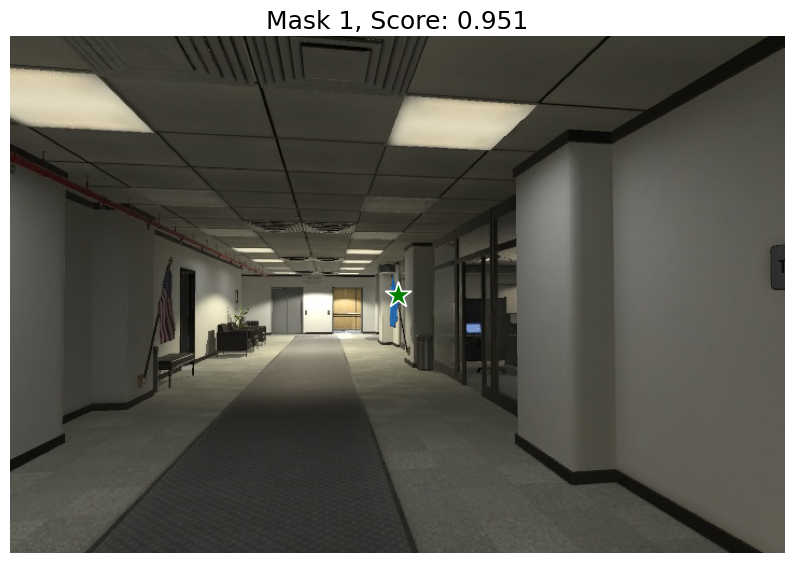

Generated 3 masks with scores: [0.9513565  0.87620044 0.5225642 ]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

# Assuming `image_files` is populated from the previous cell (aqweq8IAIwCF)
# and `cv2` is imported.

if 'image_files' in locals() and image_files:
    # Take the first image from the list for demonstration
    image_path = image_files[0]
    print(f"Loading image for segmentation: {image_path.name}")
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        print(f"Error: Could not read image {image_path.name}")
    else:
        # Convert BGR to RGB as SAM expects RGB images
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        # Set the image for the predictor
        predictor.set_image(image_rgb)

        # Define an input point (e.g., center of the image, adjust as needed)
        # For demonstration, let's pick a point roughly in the middle of the first image.
        # The specific coordinates might need adjustment based on the object you want to segment.
        input_point = np.array([[image_rgb.shape[1] // 2, image_rgb.shape[0] // 2]])
        input_label = np.array([1]) # 1 indicates a foreground point

        # Predict masks
        masks, scores, logits = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            multimask_output=True,
        )

        # Display the results
        plt.figure(figsize=(10,10))
        plt.imshow(image_rgb)
        show_points(input_point, input_label, plt.gca())

        # Display the mask with the highest score
        best_mask_idx = np.argmax(scores)
        show_mask(masks[best_mask_idx], plt.gca())
        plt.title(f"Mask {best_mask_idx+1}, Score: {scores[best_mask_idx]:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

        print(f"Generated {len(masks)} masks with scores: {scores}")

else:
    print("No image files found or 'image_files' list is not available. Please ensure the previous image loading cell ran successfully.")


If the segmentation is not as expected, you might need to adjust the `input_point` coordinates. Let's try specifying a different point to segment a particular object. You can find the coordinates by hovering over the image in the previous output plot.

[[[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]

 [[False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]
  ...
  [False False False ... False False False]
  [False False False ... False False False]
  [False False False ... False False False]]]


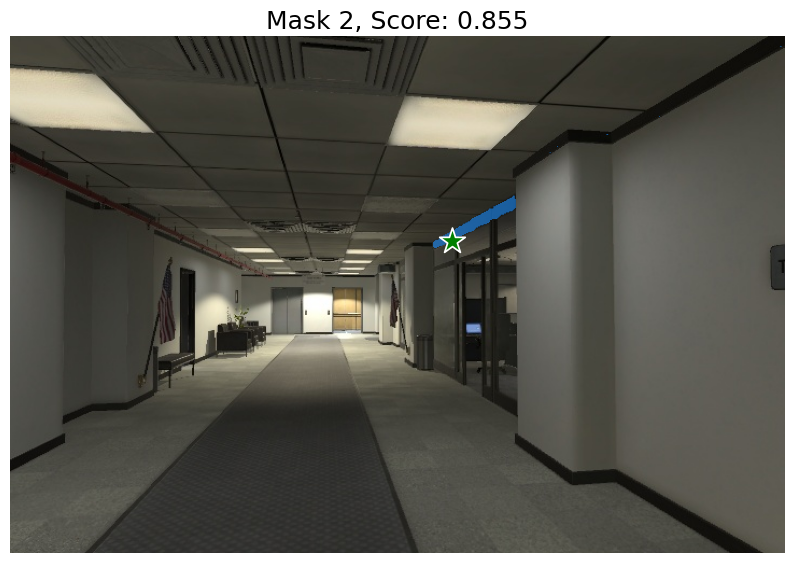

Generated 3 masks with scores: [0.73918396 0.85484815 0.67088526]


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if 'image_files' in locals() and image_files:
    image_path = image_files[0]
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        print(f"Error: Could not read image {image_path.name}")
    else:
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        predictor.set_image(image_rgb)

        # *** ADJUST THESE COORDINATES TO TARGET A SPECIFIC OBJECT ***
        # For example, to segment an object at (X, Y) pixels.
        # Replace X and Y with your desired coordinates.
        # Example: input_point = np.array([[100, 200]]) # X=100, Y=200
        input_point = np.array([[image_rgb.shape[1] // 2 + 50, image_rgb.shape[0] // 2 - 50]]) # Example: slightly offset from center
        input_label = np.array([1]) # 1 indicates a foreground point

        masks, scores, logits = predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            multimask_output=True,
        )

        print(masks)

        plt.figure(figsize=(10,10))
        plt.imshow(image_rgb)
        show_points(input_point, input_label, plt.gca())

        best_mask_idx = np.argmax(scores)
        show_mask(masks[best_mask_idx], plt.gca())
        plt.title(f"Mask {best_mask_idx+1}, Score: {scores[best_mask_idx]:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

        print(f"Generated {len(masks)} masks with scores: {scores}")
else:
    print("No image files found or 'image_files' list is not available.")


## DeepLabV3+ Segmentation Implementation

Now, let's implement DeepLabV3+ for semantic segmentation. We will use a pre-trained model from `torchvision`.

In [ ]:
import torchvision.transforms as T
import torchvision
from PIL import Image
import torch
import matplotlib.pyplot as plt


# Define the device (ensure it's available for DeepLabV3+ model)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load a pre-trained DeepLabV3+ model with a ResNet101 backbone
# We'll set pretrained=True to use the weights trained on COCO dataset
model_deeplab = torchvision.models.segmentation.deeplabv3_resnet101(weights=torchvision.models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT)
model_deeplab.eval() # Set the model to evaluation mode
model_deeplab.to(device) # Move the model to the same device as SAM (CPU or GPU)

print(f"DeepLabV3+ model loaded successfully on device: {device}")

DeepLabV3+ model loaded successfully on device: cpu


Next, we will apply the DeepLabV3+ model to the same image we used for SAM and visualize the predicted segmentation mask.

Loading image for DeepLabV3+ segmentation: 462154899999.jpg


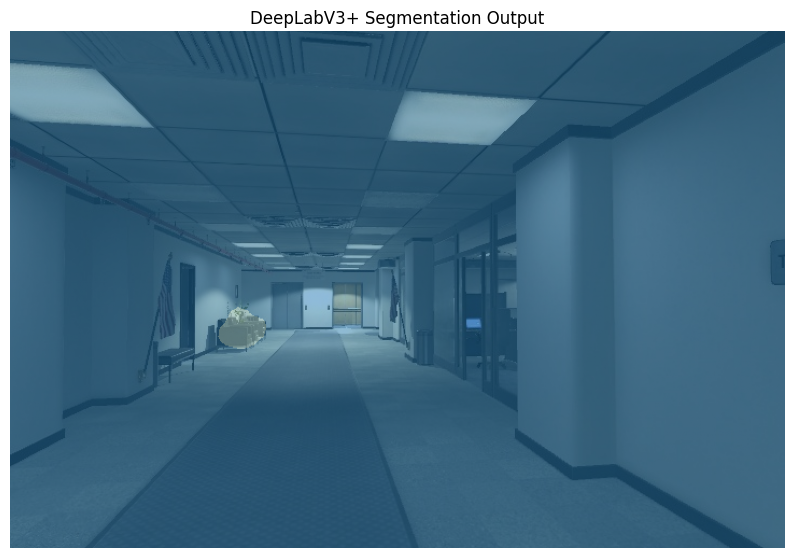

DeepLabV3+ segmentation applied and visualized.


In [ ]:
# Assuming `image_files` is available from previous cells
if 'image_files' in locals() and image_files:
    image_path = image_files[0]
    print(f"Loading image for DeepLabV3+ segmentation: {image_path.name}")
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        print(f"Error: Could not read image {image_path.name}")
    else:
        image_rgb_pil = Image.open(str(image_path)).convert("RGB")

        # Define the preprocessing transformations for DeepLabV3+
        preprocess = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        # Apply preprocessing and add a batch dimension
        input_tensor = preprocess(image_rgb_pil).unsqueeze(0).to(device)

        # Perform inference
        with torch.no_grad():
            output = model_deeplab(input_tensor)['out'][0]

        # The output is a tensor of shape [21, H, W] representing scores for each class
        # We take the argmax along the channel dimension to get the predicted class for each pixel
        output_predictions = output.argmax(0).cpu().numpy()

        # Visualize the results
        plt.figure(figsize=(10, 10))
        plt.imshow(image_rgb_pil)
        plt.imshow(output_predictions, alpha=0.5, cmap='tab20') # Overlay the segmentation mask
        plt.title('DeepLabV3+ Segmentation Output')
        plt.axis('off')
        plt.show()

        print("DeepLabV3+ segmentation applied and visualized.")
else:
    print("No image files found or 'image_files' list is not available.")


In [1]:
data = """
  Epoch 1 [0/8307] loss: 99.4855
  Epoch 1 [20/8307] loss: 64.9495
  Epoch 1 [40/8307] loss: 59.3916
  Epoch 1 [60/8307] loss: 49.6417
  Epoch 1 [80/8307] loss: 55.3742
  Epoch 1 [100/8307] loss: 52.9327
  Epoch 1 [120/8307] loss: 52.6220
  Epoch 1 [140/8307] loss: 48.3341
  Epoch 1 [160/8307] loss: 45.4274
  Epoch 1 [180/8307] loss: 43.7239
  Epoch 1 [200/8307] loss: 37.0872
  Epoch 1 [220/8307] loss: 41.1109
  Epoch 1 [240/8307] loss: 40.0525
  Epoch 1 [260/8307] loss: 32.0764
  Epoch 1 [280/8307] loss: 31.2962
  Epoch 1 [300/8307] loss: 37.1311
  Epoch 1 [320/8307] loss: 33.3097
  Epoch 1 [340/8307] loss: 28.1826
  Epoch 1 [360/8307] loss: 40.2945
  Epoch 1 [380/8307] loss: 32.5932
  Epoch 1 [400/8307] loss: 29.4674
  Epoch 1 [420/8307] loss: 31.9422
  Epoch 1 [440/8307] loss: 31.8070
  Epoch 1 [460/8307] loss: 42.3531
  Epoch 1 [480/8307] loss: 44.1492
  Epoch 1 [500/8307] loss: 35.1749
  Epoch 1 [520/8307] loss: 42.9186
  Epoch 1 [540/8307] loss: 35.1114
  Epoch 1 [560/8307] loss: 36.8199
  Epoch 1 [580/8307] loss: 42.0586
  Epoch 1 [600/8307] loss: 36.2234
  Epoch 1 [620/8307] loss: 25.5488
  Epoch 1 [640/8307] loss: 29.1039
  Epoch 1 [660/8307] loss: 33.1191
  Epoch 1 [680/8307] loss: 30.0431
  Epoch 1 [700/8307] loss: 32.8469
  Epoch 1 [720/8307] loss: 26.6152
  Epoch 1 [740/8307] loss: 26.9714
  Epoch 1 [760/8307] loss: 35.6984
  Epoch 1 [780/8307] loss: 25.6039
  Epoch 1 [800/8307] loss: 29.6199
  Epoch 1 [820/8307] loss: 39.4229
  Epoch 1 [840/8307] loss: 32.5495
  Epoch 1 [860/8307] loss: 25.9277
  Epoch 1 [880/8307] loss: 30.1566
  Epoch 1 [900/8307] loss: 33.8939
  Epoch 1 [920/8307] loss: 28.8518
  Epoch 1 [940/8307] loss: 33.0473
  Epoch 1 [960/8307] loss: 29.3864
  Epoch 1 [980/8307] loss: 30.8901
  Epoch 1 [1000/8307] loss: 29.7255
  Epoch 1 [1020/8307] loss: 26.7301
  Epoch 1 [1040/8307] loss: 36.5248
  Epoch 1 [1060/8307] loss: 31.2313
  Epoch 1 [1080/8307] loss: 30.7782
  Epoch 1 [1100/8307] loss: 28.9561
  Epoch 1 [1120/8307] loss: 29.0878
  Epoch 1 [1140/8307] loss: 28.1908
  Epoch 1 [1160/8307] loss: 27.6347
  Epoch 1 [1180/8307] loss: 22.2199
  Epoch 1 [1200/8307] loss: 32.0634
  Epoch 1 [1220/8307] loss: 32.9984
  Epoch 1 [1240/8307] loss: 31.5351
  Epoch 1 [1260/8307] loss: 35.3155
  Epoch 1 [1280/8307] loss: 36.0955
  Epoch 1 [1300/8307] loss: 37.9476
  Epoch 1 [1320/8307] loss: 33.2199
  Epoch 1 [1340/8307] loss: 24.1306
  Epoch 1 [1360/8307] loss: 34.1388
  Epoch 1 [1380/8307] loss: 29.9839
  Epoch 1 [1400/8307] loss: 24.7413
  Epoch 1 [1420/8307] loss: 37.1551
  Epoch 1 [1440/8307] loss: 28.9278
  Epoch 1 [1460/8307] loss: 27.8932
  Epoch 1 [1480/8307] loss: 25.4397
  Epoch 1 [1500/8307] loss: 28.4389
  Epoch 1 [1520/8307] loss: 32.5688
  Epoch 1 [1540/8307] loss: 24.6055
  Epoch 1 [1560/8307] loss: 29.8201
  Epoch 1 [1580/8307] loss: 23.5393
  Epoch 1 [1600/8307] loss: 33.1979
  Epoch 1 [1620/8307] loss: 34.4365
  Epoch 1 [1640/8307] loss: 31.7136
  Epoch 1 [1660/8307] loss: 28.3344
  Epoch 1 [1680/8307] loss: 26.2301
  Epoch 1 [1700/8307] loss: 23.4062
  Epoch 1 [1720/8307] loss: 27.1888
  Epoch 1 [1740/8307] loss: 26.7735
  Epoch 1 [1760/8307] loss: 39.8205
  Epoch 1 [1780/8307] loss: 32.9210
  Epoch 1 [1800/8307] loss: 32.1165
  Epoch 1 [1820/8307] loss: 27.2354
  Epoch 1 [1840/8307] loss: 29.5409
  Epoch 1 [1860/8307] loss: 27.4682
  Epoch 1 [1880/8307] loss: 31.1617
  Epoch 1 [1900/8307] loss: 32.4196
  Epoch 1 [1920/8307] loss: 23.8042
  Epoch 1 [1940/8307] loss: 24.0902
  Epoch 1 [1960/8307] loss: 29.4683
  Epoch 1 [1980/8307] loss: 32.0501
  Epoch 1 [2000/8307] loss: 22.6642
  Epoch 1 [2020/8307] loss: 32.3491
  Epoch 1 [2040/8307] loss: 26.6057
  Epoch 1 [2060/8307] loss: 25.6752
  Epoch 1 [2080/8307] loss: 31.1215
  Epoch 1 [2100/8307] loss: 28.6492
  Epoch 1 [2120/8307] loss: 24.2223
  Epoch 1 [2140/8307] loss: 30.1458
  Epoch 1 [2160/8307] loss: 34.1303
  Epoch 1 [2180/8307] loss: 28.2930
  Epoch 1 [2200/8307] loss: 28.1557
  Epoch 1 [2220/8307] loss: 26.2390
  Epoch 1 [2240/8307] loss: 24.2386
  Epoch 1 [2260/8307] loss: 26.4705
  Epoch 1 [2280/8307] loss: 31.7462
  Epoch 1 [2300/8307] loss: 26.5584
  Epoch 1 [2320/8307] loss: 22.4310
  Epoch 1 [2340/8307] loss: 26.6625
  Epoch 1 [2360/8307] loss: 37.8071
  Epoch 1 [2380/8307] loss: 23.3543
  Epoch 1 [2400/8307] loss: 23.5582
  Epoch 1 [2420/8307] loss: 31.5944
  Epoch 1 [2440/8307] loss: 26.1518
  Epoch 1 [2460/8307] loss: 26.0343
  Epoch 1 [2480/8307] loss: 26.3759
  Epoch 1 [2500/8307] loss: 21.8117
  Epoch 1 [2520/8307] loss: 26.4840
  Epoch 1 [2540/8307] loss: 22.7029
  Epoch 1 [2560/8307] loss: 28.4734
  Epoch 1 [2580/8307] loss: 23.6250
  Epoch 1 [2600/8307] loss: 20.7728
  Epoch 1 [2620/8307] loss: 20.7976
  Epoch 1 [2640/8307] loss: 25.8193
  Epoch 1 [2660/8307] loss: 27.1717
  Epoch 1 [2680/8307] loss: 30.6530
  Epoch 1 [2700/8307] loss: 21.0111
  Epoch 1 [2720/8307] loss: 33.5189
  Epoch 1 [2740/8307] loss: 26.8743
  Epoch 1 [2760/8307] loss: 30.4917
  Epoch 1 [2780/8307] loss: 28.7430
  Epoch 1 [2800/8307] loss: 26.7937
  Epoch 1 [2820/8307] loss: 21.9528
  Epoch 1 [2840/8307] loss: 28.5990
  Epoch 1 [2860/8307] loss: 24.2534
  Epoch 1 [2880/8307] loss: 27.5280
  Epoch 1 [2900/8307] loss: 29.5006
  Epoch 1 [2920/8307] loss: 31.5873
  Epoch 1 [2940/8307] loss: 30.4005
  Epoch 1 [2960/8307] loss: 26.1073
  Epoch 1 [2980/8307] loss: 26.3751
  Epoch 1 [3000/8307] loss: 24.4072
  Epoch 1 [3020/8307] loss: 28.5750
  Epoch 1 [3040/8307] loss: 22.6115
  Epoch 1 [3060/8307] loss: 27.2048
  Epoch 1 [3080/8307] loss: 25.0857
  Epoch 1 [3100/8307] loss: 26.8825
  Epoch 1 [3120/8307] loss: 34.7450
  Epoch 1 [3140/8307] loss: 32.6741
  Epoch 1 [3160/8307] loss: 38.0976
  Epoch 1 [3180/8307] loss: 32.1381
  Epoch 1 [3200/8307] loss: 27.5630
  Epoch 1 [3220/8307] loss: 27.0256
  Epoch 1 [3240/8307] loss: 25.1292
  Epoch 1 [3260/8307] loss: 29.6286
  Epoch 1 [3280/8307] loss: 30.7109
  Epoch 1 [3300/8307] loss: 23.0181
  Epoch 1 [3320/8307] loss: 23.6000
  Epoch 1 [3340/8307] loss: 24.6831
  Epoch 1 [3360/8307] loss: 27.9362
  Epoch 1 [3380/8307] loss: 24.5239
  Epoch 1 [3400/8307] loss: 26.9069
  Epoch 1 [3420/8307] loss: 24.4124
  Epoch 1 [3440/8307] loss: 24.6009
  Epoch 1 [3460/8307] loss: 23.6658
  Epoch 1 [3480/8307] loss: 23.0689
  Epoch 1 [3500/8307] loss: 21.6825
  Epoch 1 [3520/8307] loss: 23.5431
  Epoch 1 [3540/8307] loss: 22.4524
  Epoch 1 [3560/8307] loss: 23.6074
  Epoch 1 [3580/8307] loss: 28.5748
  Epoch 1 [3600/8307] loss: 25.8805
  Epoch 1 [3620/8307] loss: 25.0724
  Epoch 1 [3640/8307] loss: 25.3755
  Epoch 1 [3660/8307] loss: 24.2496
  Epoch 1 [3680/8307] loss: 25.5524
  Epoch 1 [3700/8307] loss: 26.3929
  Epoch 1 [3720/8307] loss: 25.8328
  Epoch 1 [3740/8307] loss: 35.0517
  Epoch 1 [3760/8307] loss: 20.9195
  Epoch 1 [3780/8307] loss: 28.6542
  Epoch 1 [3800/8307] loss: 27.9265
  Epoch 1 [3820/8307] loss: 23.8561
  Epoch 1 [3840/8307] loss: 23.3362
  Epoch 1 [3860/8307] loss: 28.4317
  Epoch 1 [3880/8307] loss: 29.6167
  Epoch 1 [3900/8307] loss: 28.8655
  Epoch 1 [3920/8307] loss: 26.8547
  Epoch 1 [3940/8307] loss: 28.9474
  Epoch 1 [3960/8307] loss: 21.1287
  Epoch 1 [3980/8307] loss: 29.6257
  Epoch 1 [4000/8307] loss: 29.9460
  Epoch 1 [4020/8307] loss: 24.0108
  Epoch 1 [4040/8307] loss: 28.8690
  Epoch 1 [4060/8307] loss: 22.8740
  Epoch 1 [4080/8307] loss: 27.7117
  Epoch 1 [4100/8307] loss: 25.9869
  Epoch 1 [4120/8307] loss: 24.5702
  Epoch 1 [4140/8307] loss: 29.8392
  Epoch 1 [4160/8307] loss: 26.8697
  Epoch 1 [4180/8307] loss: 25.1455
  Epoch 1 [4200/8307] loss: 23.5806
  Epoch 1 [4220/8307] loss: 24.8656
  Epoch 1 [4240/8307] loss: 25.3522
  Epoch 1 [4260/8307] loss: 28.1006
  Epoch 1 [4280/8307] loss: 28.3583
  Epoch 1 [4300/8307] loss: 31.2037
  Epoch 1 [4320/8307] loss: 23.2383
  Epoch 1 [4340/8307] loss: 23.7915
  Epoch 1 [4360/8307] loss: 21.6806
  Epoch 1 [4380/8307] loss: 32.2983
  Epoch 1 [4400/8307] loss: 28.3490
  Epoch 1 [4420/8307] loss: 25.3255
  Epoch 1 [4440/8307] loss: 27.8305
  Epoch 1 [4460/8307] loss: 32.8910
  Epoch 1 [4480/8307] loss: 22.9373
  Epoch 1 [4500/8307] loss: 19.8068
  Epoch 1 [4520/8307] loss: 31.1374
  Epoch 1 [4540/8307] loss: 21.9749
  Epoch 1 [4560/8307] loss: 24.0373
  Epoch 1 [4580/8307] loss: 22.2135
  Epoch 1 [4600/8307] loss: 26.1047
  Epoch 1 [4620/8307] loss: 29.3730
  Epoch 1 [4640/8307] loss: 24.3840
  Epoch 1 [4660/8307] loss: 25.5678
  Epoch 1 [4680/8307] loss: 19.6042
  Epoch 1 [4700/8307] loss: 23.4350
  Epoch 1 [4720/8307] loss: 30.5849
  Epoch 1 [4740/8307] loss: 27.6382
  Epoch 1 [4760/8307] loss: 26.7169
  Epoch 1 [4780/8307] loss: 22.9408
  Epoch 1 [4800/8307] loss: 22.1334
  Epoch 1 [4820/8307] loss: 21.5577
  Epoch 1 [4840/8307] loss: 26.8847
  Epoch 1 [4860/8307] loss: 25.8155
  Epoch 1 [4880/8307] loss: 30.0133
  Epoch 1 [4900/8307] loss: 26.3285
  Epoch 1 [4920/8307] loss: 26.6338
  Epoch 1 [4940/8307] loss: 26.4401
  Epoch 1 [4960/8307] loss: 28.3170
  Epoch 1 [4980/8307] loss: 35.1198
  Epoch 1 [5000/8307] loss: 30.0633
  Epoch 1 [5020/8307] loss: 26.9454
  Epoch 1 [5040/8307] loss: 26.5643
  Epoch 1 [5060/8307] loss: 27.7418
  Epoch 1 [5080/8307] loss: 28.9375
  Epoch 1 [5100/8307] loss: 27.7845
  Epoch 1 [5120/8307] loss: 31.1133
  Epoch 1 [5140/8307] loss: 27.8727
  Epoch 1 [5160/8307] loss: 25.9572
  Epoch 1 [5180/8307] loss: 27.2251
  Epoch 1 [5200/8307] loss: 32.8626
  Epoch 1 [5220/8307] loss: 22.6103
  Epoch 1 [5240/8307] loss: 23.7428
  Epoch 1 [5260/8307] loss: 22.0802
  Epoch 1 [5280/8307] loss: 28.1111
  Epoch 1 [5300/8307] loss: 26.2163
  Epoch 1 [5320/8307] loss: 24.2933
  Epoch 1 [5340/8307] loss: 31.5462
  Epoch 1 [5360/8307] loss: 29.2764
  Epoch 1 [5380/8307] loss: 27.9242
  Epoch 1 [5400/8307] loss: 32.1862
  Epoch 1 [5420/8307] loss: 21.9887
  Epoch 1 [5440/8307] loss: 26.6177
  Epoch 1 [5460/8307] loss: 23.6115
  Epoch 1 [5480/8307] loss: 26.6959
  Epoch 1 [5500/8307] loss: 21.1088
  Epoch 1 [5520/8307] loss: 26.6805
  Epoch 1 [5540/8307] loss: 23.4873
  Epoch 1 [5560/8307] loss: 22.5322
  Epoch 1 [5580/8307] loss: 25.7623
  Epoch 1 [5600/8307] loss: 26.6532
  Epoch 1 [5620/8307] loss: 21.9299
  Epoch 1 [5640/8307] loss: 28.5840
  Epoch 1 [5660/8307] loss: 24.5919
  Epoch 1 [5680/8307] loss: 19.7733
  Epoch 1 [5700/8307] loss: 21.6590
  Epoch 1 [5720/8307] loss: 28.8190
  Epoch 1 [5740/8307] loss: 31.9933
  Epoch 1 [5760/8307] loss: 35.4654
  Epoch 1 [5780/8307] loss: 28.5861
  Epoch 1 [5800/8307] loss: 22.8245
  Epoch 1 [5820/8307] loss: 22.3765
  Epoch 1 [5840/8307] loss: 29.5205
  Epoch 1 [5860/8307] loss: 29.5459
  Epoch 1 [5880/8307] loss: 20.4394
  Epoch 1 [5900/8307] loss: 24.8190
  Epoch 1 [5920/8307] loss: 23.8070
  Epoch 1 [5940/8307] loss: 21.1095
  Epoch 1 [5960/8307] loss: 33.0544
  Epoch 1 [5980/8307] loss: 22.7342
  Epoch 1 [6000/8307] loss: 28.4803
  Epoch 1 [6020/8307] loss: 26.7384
  Epoch 1 [6040/8307] loss: 27.9613
  Epoch 1 [6060/8307] loss: 25.2098
  Epoch 1 [6080/8307] loss: 22.3450
  Epoch 1 [6100/8307] loss: 29.4298
  Epoch 1 [6120/8307] loss: 24.6640
  Epoch 1 [6140/8307] loss: 29.9767
  Epoch 1 [6160/8307] loss: 27.8248
  Epoch 1 [6180/8307] loss: 26.5150
  Epoch 1 [6200/8307] loss: 22.6845
  Epoch 1 [6220/8307] loss: 21.0932
  Epoch 1 [6240/8307] loss: 26.2367
  Epoch 1 [6260/8307] loss: 24.1141
  Epoch 1 [6280/8307] loss: 25.3401
  Epoch 1 [6300/8307] loss: 23.9357
  Epoch 1 [6320/8307] loss: 21.5629
  Epoch 1 [6340/8307] loss: 24.4697
  Epoch 1 [6360/8307] loss: 23.8344
  Epoch 1 [6380/8307] loss: 22.1899
  Epoch 1 [6400/8307] loss: 27.0929
  Epoch 1 [6420/8307] loss: 26.4593
  Epoch 1 [6440/8307] loss: 23.3768
  Epoch 1 [6460/8307] loss: 26.6548
  Epoch 1 [6480/8307] loss: 27.1089
  Epoch 1 [6500/8307] loss: 29.6789
  Epoch 1 [6520/8307] loss: 24.2529
  Epoch 1 [6540/8307] loss: 34.0473
  Epoch 1 [6560/8307] loss: 20.9779
  Epoch 1 [6580/8307] loss: 23.1356
  Epoch 1 [6600/8307] loss: 30.2569
  Epoch 1 [6620/8307] loss: 33.2659
  Epoch 1 [6640/8307] loss: 25.6579
  Epoch 1 [6660/8307] loss: 23.5355
  Epoch 1 [6680/8307] loss: 22.0281
  Epoch 1 [6700/8307] loss: 27.3282
  Epoch 1 [6720/8307] loss: 21.9486
  Epoch 1 [6740/8307] loss: 29.7492
  Epoch 1 [6760/8307] loss: 22.0411
  Epoch 1 [6780/8307] loss: 24.5216
  Epoch 1 [6800/8307] loss: 22.2386
  Epoch 1 [6820/8307] loss: 38.5246
  Epoch 1 [6840/8307] loss: 25.6024
  Epoch 1 [6860/8307] loss: 22.0125
  Epoch 1 [6880/8307] loss: 20.3787
  Epoch 1 [6900/8307] loss: 28.4159
  Epoch 1 [6920/8307] loss: 23.4613
  Epoch 1 [6940/8307] loss: 23.7690
  Epoch 1 [6960/8307] loss: 28.9505
  Epoch 1 [6980/8307] loss: 22.1594
  Epoch 1 [7000/8307] loss: 22.3394
  Epoch 1 [7020/8307] loss: 33.4067
  Epoch 1 [7040/8307] loss: 32.7511
  Epoch 1 [7060/8307] loss: 26.3403
  Epoch 1 [7080/8307] loss: 27.9861
  Epoch 1 [7100/8307] loss: 19.9735
  Epoch 1 [7120/8307] loss: 27.1503
  Epoch 1 [7140/8307] loss: 21.4397
  Epoch 1 [7160/8307] loss: 31.3778
  Epoch 1 [7180/8307] loss: 26.7698
  Epoch 1 [7200/8307] loss: 28.3303
  Epoch 1 [7220/8307] loss: 23.9256
  Epoch 1 [7240/8307] loss: 21.4560
  Epoch 1 [7260/8307] loss: 26.8411
  Epoch 1 [7280/8307] loss: 27.4843
  Epoch 1 [7300/8307] loss: 26.1034
  Epoch 1 [7320/8307] loss: 33.7726
  Epoch 1 [7340/8307] loss: 28.7288
  Epoch 1 [7360/8307] loss: 31.3956
  Epoch 1 [7380/8307] loss: 24.0969
  Epoch 1 [7400/8307] loss: 27.7132
  Epoch 1 [7420/8307] loss: 28.6257
  Epoch 1 [7440/8307] loss: 27.0436
  Epoch 1 [7460/8307] loss: 30.5077
  Epoch 1 [7480/8307] loss: 34.7157
  Epoch 1 [7500/8307] loss: 19.7499
  Epoch 1 [7520/8307] loss: 21.9755
  Epoch 1 [7540/8307] loss: 24.9870
  Epoch 1 [7560/8307] loss: 27.2789
  Epoch 1 [7580/8307] loss: 21.1366
  Epoch 1 [7600/8307] loss: 24.1761
  Epoch 1 [7620/8307] loss: 21.9257
  Epoch 1 [7640/8307] loss: 25.8758
  Epoch 1 [7660/8307] loss: 29.4275
  Epoch 1 [7680/8307] loss: 27.3207
  Epoch 1 [7700/8307] loss: 23.4876
  Epoch 1 [7720/8307] loss: 23.4160
  Epoch 1 [7740/8307] loss: 29.6307
  Epoch 1 [7760/8307] loss: 22.6531
  Epoch 1 [7780/8307] loss: 25.8208
  Epoch 1 [7800/8307] loss: 20.9707
  Epoch 1 [7820/8307] loss: 20.0538
  Epoch 1 [7840/8307] loss: 22.6261
  Epoch 1 [7860/8307] loss: 24.9533
  Epoch 1 [7880/8307] loss: 20.5517
  Epoch 1 [7900/8307] loss: 28.8428
  Epoch 1 [7920/8307] loss: 25.1377
  Epoch 1 [7940/8307] loss: 27.2615
  Epoch 1 [7960/8307] loss: 29.6632
  Epoch 1 [7980/8307] loss: 22.0850
  Epoch 1 [8000/8307] loss: 24.2573
  Epoch 1 [8020/8307] loss: 26.4399
  Epoch 1 [8040/8307] loss: 28.4708
  Epoch 1 [8060/8307] loss: 20.0046
  Epoch 1 [8080/8307] loss: 28.0579
  Epoch 1 [8100/8307] loss: 22.9094
  Epoch 1 [8120/8307] loss: 26.3312
  Epoch 1 [8140/8307] loss: 25.6695
  Epoch 1 [8160/8307] loss: 23.7777
  Epoch 1 [8180/8307] loss: 21.1486
  Epoch 1 [8200/8307] loss: 26.8336
  Epoch 1 [8220/8307] loss: 25.0946
  Epoch 1 [8240/8307] loss: 29.2735
  Epoch 1 [8260/8307] loss: 24.4229
  Epoch 1 [8280/8307] loss: 26.2507
  Epoch 1 [8300/8307] loss: 23.2599"""

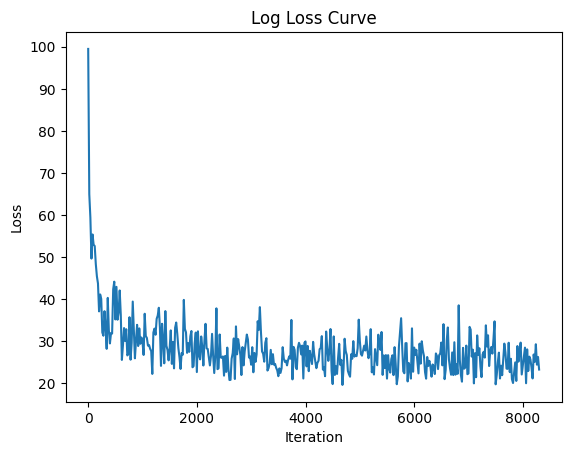

In [2]:
import matplotlib.pyplot as plt
import re

# Extract loss values from the log
loss_values = []
iteration_numbers = []
for line in data.split('\n'):
    match = re.search(r'Epoch 1 \[(\d+)/8307\] loss: (\d+\.\d+)', line)
    if match:
        iteration_numbers.append(int(match.group(1)))
        loss_values.append(float(match.group(2)))

# Plot the loss curve
plt.plot(iteration_numbers, loss_values)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Log Loss Curve')
plt.show()